# Week 3: Improve Model

Goal: improve the Week 2 CNN-LSTM image captioning baseline and compare it with an improved encoder-decoder model.

Main tasks:
- use ResNet50 or EfficientNet as encoder
- add dropout
- tune learning rate and batch size
- compare baseline vs improved model
- plot training/validation loss
- show good and bad caption examples


## 1. Imports and setup

This notebook continues the Flickr8k image captioning project. Run it after the Week 2 preprocessing notebook, or run all cells here from the beginning.

In [1]:
!pip install opendatasets nltk scikit-learn matplotlib

import os
import re
import string
import random
from collections import Counter

import numpy as np
import pandas as pd
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import torchvision.transforms as transforms
import torchvision.models as models

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from nltk.translate.bleu_score import corpus_bleu, sentence_bleu, SmoothingFunction

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


## 2. Load captions and images


In [5]:
os.environ["KAGGLE_USERNAME"] = "Ayanat Kanat"
os.environ["KAGGLE_KEY"] = "KGAT_ba09b76bb3e3c9975fa52c9b91dce7d9"

In [6]:
!pip install kaggle -q

In [7]:
!kaggle datasets download -d adityajn105/flickr8k -p /content/flickr8k --unzip

Dataset URL: https://www.kaggle.com/datasets/adityajn105/flickr8k
License(s): CC0-1.0
100% 1.04G/1.04G [00:06<00:00, 173MB/s]



In [8]:
text_path = "/content/flickr8k/captions.txt"
images_path = "/content/flickr8k/Images"

df = pd.read_csv(text_path)

print("Rows:", len(df))
print("Images:", df["image"].nunique())

Rows: 40455
Images: 8091


## 3. Clean captions and add tokens

In [9]:
def clean_caption(text):
    text = str(text).lower()
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_caption"] = df["caption"].apply(clean_caption)
df["caption_tokens"] = df["clean_caption"].apply(lambda x: "<start> " + x + " <end>")

df[["image", "caption", "caption_tokens"]].head()

,image,caption,caption_tokens
0,1000268201_693b08cb0e.jpg,A child in a pink dress is climbing up a set o...,<start> a child in a pink dress is climbing up...
1,1000268201_693b08cb0e.jpg,A girl going into a wooden building .,<start> a girl going into a wooden building <end>
2,1000268201_693b08cb0e.jpg,A little girl climbing into a wooden playhouse .,<start> a little girl climbing into a wooden p...
3,1000268201_693b08cb0e.jpg,A little girl climbing the stairs to her playh...,<start> a little girl climbing the stairs to h...
4,1000268201_693b08cb0e.jpg,A little girl in a pink dress going into a woo...,<start> a little girl in a pink dress going in...


## 4. Train / validation / test split by image

We split by unique image names, not by caption rows. This prevents data leakage.

In [10]:
unique_images = df["image"].unique()

train_imgs, temp_imgs = train_test_split(unique_images, test_size=0.20, random_state=SEED)
val_imgs, test_imgs = train_test_split(temp_imgs, test_size=0.50, random_state=SEED)

train_df = df[df["image"].isin(train_imgs)].reset_index(drop=True)
val_df = df[df["image"].isin(val_imgs)].reset_index(drop=True)
test_df = df[df["image"].isin(test_imgs)].reset_index(drop=True)

print("Train images:", len(train_imgs), "captions:", len(train_df))
print("Val images:", len(val_imgs), "captions:", len(val_df))
print("Test images:", len(test_imgs), "captions:", len(test_df))

Train images: 6472 captions: 32360
Val images: 809 captions: 4045
Test images: 810 captions: 4050


## 5. Build vocabulary from training captions

In [11]:
MIN_FREQ = 5

counter = Counter()
for caption in train_df["caption_tokens"]:
    counter.update(caption.split())

special_tokens = ["<pad>", "<start>", "<end>", "<unk>"]
words = [word for word, count in counter.items() if count >= MIN_FREQ and word not in special_tokens]

itos = special_tokens + sorted(words)
stoi = {word: idx for idx, word in enumerate(itos)}

PAD_IDX = stoi["<pad>"]
START_IDX = stoi["<start>"]
END_IDX = stoi["<end>"]
UNK_IDX = stoi["<unk>"]

vocab_size = len(itos)
print("Vocabulary size:", vocab_size)

def encode_caption(caption):
    return [stoi.get(token, UNK_IDX) for token in caption.split()]

for split_df in [train_df, val_df, test_df]:
    split_df["encoded"] = split_df["caption_tokens"].apply(encode_caption)

train_df.head()

Vocabulary size: 2655


,image,caption,clean_caption,caption_tokens,encoded
0,1000268201_693b08cb0e.jpg,A child in a pink dress is climbing up a set o...,a child in a pink dress is climbing up a set o...,<start> a child in a pink dress is climbing up...,"[1, 11, 443, 1133, 11, 1659, 681, 1161, 473, 2..."
1,1000268201_693b08cb0e.jpg,A girl going into a wooden building .,a girl going into a wooden building,<start> a girl going into a wooden building <end>,"[1, 11, 937, 956, 1160, 11, 2625, 322, 2]"
2,1000268201_693b08cb0e.jpg,A little girl climbing into a wooden playhouse .,a little girl climbing into a wooden playhouse,<start> a little girl climbing into a wooden p...,"[1, 11, 1306, 937, 473, 1160, 11, 2625, 1686, 2]"
3,1000268201_693b08cb0e.jpg,A little girl climbing the stairs to her playh...,a little girl climbing the stairs to her playh...,<start> a little girl climbing the stairs to h...,"[1, 11, 1306, 937, 473, 2357, 2184, 2397, 1059..."
4,1000268201_693b08cb0e.jpg,A little girl in a pink dress going into a woo...,a little girl in a pink dress going into a woo...,<start> a little girl in a pink dress going in...,"[1, 11, 1306, 937, 1133, 11, 1659, 681, 956, 1..."


## 6. Extract image features with baseline and improved encoders

For comparison, this notebook supports:
- **Baseline:** VGG16 + LSTM
- **Improved:** ResNet50 + LSTM with dropout

In [12]:
# Find correct image folder automatically

jpg_folders = []

for root, dirs, files in os.walk("/content"):
    jpg_count = len([f for f in files if f.lower().endswith(".jpg")])
    if jpg_count > 0:
        jpg_folders.append((root, jpg_count))

print("Folders with jpg images:")
for folder, count in jpg_folders:
    print(folder, count)

# choose folder with most images
images_path = max(jpg_folders, key=lambda x: x[1])[0]

print("\nSelected images_path:", images_path)

# test first image
first_image = df["image"].iloc[0]
print("First image:", first_image)
print("Full path:", os.path.join(images_path, first_image))
print("Exists:", os.path.exists(os.path.join(images_path, first_image)))

Folders with jpg images:
/content/flickr8k/Images 8091

Selected images_path: /content/flickr8k/Images
First image: 1000268201_693b08cb0e.jpg
Full path: /content/flickr8k/Images/1000268201_693b08cb0e.jpg
Exists: True


In [14]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


def build_feature_extractor(encoder_name):
    encoder_name = encoder_name.lower()

    if encoder_name == "vgg16":
        weights = models.VGG16_Weights.DEFAULT
        model = models.vgg16(weights=weights)

        cnn = model.features
        avgpool = model.avgpool
        classifier_part = nn.Sequential(*list(model.classifier.children())[:-1])

        class VGGFeatureExtractor(nn.Module):
            def __init__(self, cnn, avgpool, classifier_part):
                super().__init__()
                self.cnn = cnn
                self.avgpool = avgpool
                self.classifier_part = classifier_part

            def forward(self, x):
                x = self.cnn(x)
                x = self.avgpool(x)
                x = torch.flatten(x, 1)
                x = self.classifier_part(x)
                return x

        feature_extractor = VGGFeatureExtractor(cnn, avgpool, classifier_part)
        feature_dim = 4096

    elif encoder_name == "resnet50":
        weights = models.ResNet50_Weights.DEFAULT
        model = models.resnet50(weights=weights)
        feature_extractor = nn.Sequential(*list(model.children())[:-1])
        feature_dim = 2048

    else:
        raise ValueError("encoder_name must be 'vgg16' or 'resnet50'")

    feature_extractor = feature_extractor.to(device)
    feature_extractor.eval()

    for p in feature_extractor.parameters():
        p.requires_grad = False

    return feature_extractor, feature_dim


def extract_features(image_names, encoder_name="resnet50", batch_size=64, save_dir="features"):
    os.makedirs(save_dir, exist_ok=True)

    save_path = os.path.join(save_dir, f"image_features_{encoder_name}.pt")

    if os.path.exists(save_path):
        print("Loading saved features:", save_path)
        return torch.load(save_path, map_location="cpu")

    feature_extractor, feature_dim = build_feature_extractor(encoder_name)

    features = {}
    image_names = list(image_names)

    for i in tqdm(range(0, len(image_names), batch_size)):
        batch_names = image_names[i:i + batch_size]
        images = []

        for image_name in batch_names:
            img_path = os.path.join(images_path, image_name)

            if not os.path.exists(img_path):
                continue

            image = Image.open(img_path).convert("RGB")
            images.append(transform(image))

        if len(images) == 0:
            continue

        images = torch.stack(images).to(device)

        with torch.no_grad():
            batch_features = feature_extractor(images)
            batch_features = batch_features.view(batch_features.size(0), -1).cpu()

        for image_name, feature in zip(batch_names, batch_features):
            features[image_name] = feature

    torch.save(features, save_path)

    print("Saved features:", save_path)
    print("Feature dimension:", feature_dim)
    print("Extracted features:", len(features))

    return features

In [15]:
all_images = df["image"].unique()

# Baseline features: VGG16
vgg16_features = extract_features(
    all_images,
    encoder_name="vgg16",
    batch_size=32
)

# Improved features: ResNet50
resnet50_features = extract_features(
    all_images,
    encoder_name="resnet50",
    batch_size=64
)

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:04<00:00, 129MB/s]


  0%|          | 0/253 [00:00<?, ?it/s]

Saved features: features/image_features_vgg16.pt
Feature dimension: 4096
Extracted features: 8091
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 167MB/s]


  0%|          | 0/127 [00:00<?, ?it/s]

Saved features: features/image_features_resnet50.pt
Feature dimension: 2048
Extracted features: 8091


## 7. Dataset and DataLoader

In [16]:
class Flickr8kCaptionDataset(Dataset):
    def __init__(self, dataframe, image_features):
        self.df = dataframe.reset_index(drop=True)
        self.image_features = image_features

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image_name = row["image"]
        feature = self.image_features[image_name]
        caption = torch.tensor(row["encoded"], dtype=torch.long)
        return feature, caption, image_name

def collate_fn(batch):
    features, captions, image_names = zip(*batch)
    features = torch.stack(features)

    max_len = max(len(c) for c in captions)
    padded = torch.full((len(captions), max_len), PAD_IDX, dtype=torch.long)

    for i, caption in enumerate(captions):
        padded[i, :len(caption)] = caption

    return features, padded, image_names

def make_loaders(image_features, batch_size):
    train_dataset = Flickr8kCaptionDataset(train_df, image_features)
    val_dataset = Flickr8kCaptionDataset(val_df, image_features)
    test_dataset = Flickr8kCaptionDataset(test_df, image_features)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_fn)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)

    return train_loader, val_loader, test_loader

## 8. CNN-LSTM model with optional dropout

The improved model uses dropout in the feature projection, embeddings, and LSTM output before the final classifier.

In [17]:
class CNNLSTMCaptioner(nn.Module):
    def __init__(self, vocab_size, feature_dim, embed_dim=256, hidden_dim=512, pad_idx=0, dropout=0.0):
        super().__init__()
        self.feature_proj = nn.Linear(feature_dim, embed_dim)
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.dropout = nn.Dropout(dropout)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, features, captions):
        # teacher forcing: model sees all tokens except the last one
        caption_input = captions[:, :-1]

        img_embed = self.dropout(self.feature_proj(features)).unsqueeze(1)
        word_embed = self.dropout(self.embedding(caption_input))

        lstm_input = torch.cat([img_embed, word_embed], dim=1)
        output, _ = self.lstm(lstm_input)
        output = self.dropout(output)
        logits = self.fc(output)
        return logits

## 9. Training and validation functions

In [18]:
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss = 0

    for features, captions, _ in tqdm(loader):
        features = features.to(device)
        captions = captions.to(device)

        logits = model(features, captions)
        targets = captions

        loss = criterion(logits.reshape(-1, vocab_size), targets.reshape(-1))

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

def validate_one_epoch(model, loader, criterion):
    model.eval()
    total_loss = 0

    with torch.no_grad():
        for features, captions, _ in loader:
            features = features.to(device)
            captions = captions.to(device)

            logits = model(features, captions)
            targets = captions
            loss = criterion(logits.reshape(-1, vocab_size), targets.reshape(-1))
            total_loss += loss.item()

    return total_loss / len(loader)

def train_model(model_name, image_features, feature_dim, batch_size, learning_rate, dropout, epochs=5):
    train_loader, val_loader, test_loader = make_loaders(image_features, batch_size=batch_size)

    model = CNNLSTMCaptioner(
        vocab_size=vocab_size,
        feature_dim=feature_dim,
        embed_dim=256,
        hidden_dim=512,
        pad_idx=PAD_IDX,
        dropout=dropout
    ).to(device)

    criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    history = []
    best_val_loss = float("inf")
    best_path = f"{model_name.lower().replace(' ', '_')}_best.pt"

    for epoch in range(1, epochs + 1):
        train_loss = train_one_epoch(model, train_loader, criterion, optimizer)
        val_loss = validate_one_epoch(model, val_loader, criterion)

        history.append({
            "model": model_name,
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "learning_rate": learning_rate,
            "batch_size": batch_size,
            "dropout": dropout
        })

        print(f"{model_name} | Epoch {epoch}/{epochs} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), best_path)

    model.load_state_dict(torch.load(best_path, map_location=device))
    return model, pd.DataFrame(history), test_loader

## 10. Train baseline vs improved model

In [19]:
EPOCHS = 5

# Baseline: VGG16 + LSTM, no dropout
baseline_model, baseline_history, baseline_test_loader = train_model(
    model_name="VGG16 + LSTM",
    image_features=vgg16_features,
    feature_dim=4096,
    batch_size=64,
    learning_rate=1e-3,
    dropout=0.0,
    epochs=EPOCHS
)

# Improved: ResNet50 + LSTM, dropout, tuned learning rate / batch size
improved_model, improved_history, improved_test_loader = train_model(
    model_name="ResNet50 + LSTM",
    image_features=resnet50_features,
    feature_dim=2048,
    batch_size=32,
    learning_rate=5e-4,
    dropout=0.3,
    epochs=EPOCHS
)

history_df = pd.concat([baseline_history, improved_history], ignore_index=True)
history_df

  0%|          | 0/506 [00:00<?, ?it/s]

VGG16 + LSTM | Epoch 1/5 | train_loss=3.4713 | val_loss=2.9817


  0%|          | 0/506 [00:00<?, ?it/s]

VGG16 + LSTM | Epoch 2/5 | train_loss=2.7702 | val_loss=2.7187


  0%|          | 0/506 [00:00<?, ?it/s]

...

  0%|          | 0/1012 [00:00<?, ?it/s]

ResNet50 + LSTM | Epoch 4/5 | train_loss=2.5505 | val_loss=2.5765


  0%|          | 0/1012 [00:00<?, ?it/s]

ResNet50 + LSTM | Epoch 5/5 | train_loss=2.4396 | val_loss=2.5258


,model,epoch,train_loss,val_loss,learning_rate,batch_size,dropout
0,VGG16 + LSTM,1,3.471341,2.981656,0.0010,64,0.0
1,VGG16 + LSTM,2,2.770202,2.718691,0.0010,64,0.0
2,VGG16 + LSTM,3,2.506972,2.619446,0.0010,64,0.0
3,VGG16 + LSTM,4,2.323988,2.570053,0.0010,64,0.0
4,VGG16 + LSTM,5,2.174002,2.556091,0.0010,64,0.0
5,ResNet50 + LSTM,1,3.648197,3.079293,0.0005,32,0.3
6,ResNet50 + LSTM,2,2.959905,2.780377,0.0005,32,0.3
7,ResNet50 + LSTM,3,2.708376,2.646815,0.0005,32,0.3
8,ResNet50 + LSTM,4,2.550520,2.576459,0.0005,32,0.3
9,ResNet50 + LSTM,5,2.439555,2.525814,0.0005,32,0.3


## 11. Plot training and validation loss

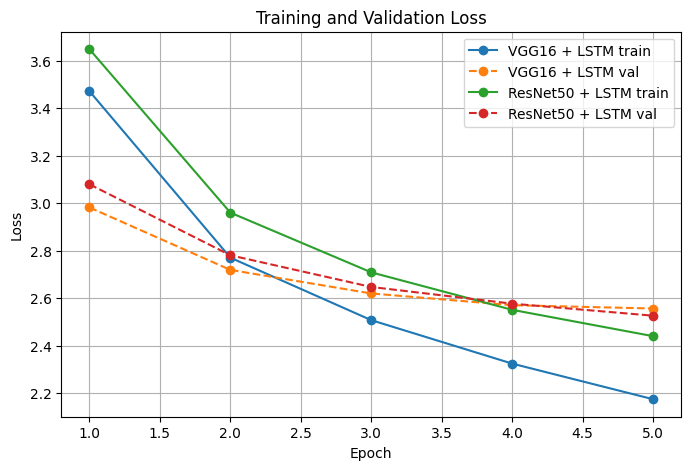

In [20]:
plt.figure(figsize=(8, 5))
for model_name in history_df["model"].unique():
    subset = history_df[history_df["model"] == model_name]
    plt.plot(subset["epoch"], subset["train_loss"], marker="o", label=f"{model_name} train")
    plt.plot(subset["epoch"], subset["val_loss"], marker="o", linestyle="--", label=f"{model_name} val")

plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

## 12. Caption generation

In [21]:
def generate_caption(model, feature, max_len=25):
    model.eval()

    generated = []
    input_word = torch.tensor([[START_IDX]], dtype=torch.long).to(device)
    feature = feature.unsqueeze(0).to(device)

    with torch.no_grad():
        img_embed = model.dropout(model.feature_proj(feature)).unsqueeze(1)
        output, hidden = model.lstm(img_embed)

        for _ in range(max_len):
            word_embed = model.embedding(input_word)
            output, hidden = model.lstm(word_embed, hidden)
            logits = model.fc(output.squeeze(1))
            predicted_idx = logits.argmax(dim=1).item()

            if predicted_idx == END_IDX:
                break

            predicted_word = itos[predicted_idx]
            if predicted_word not in ["<start>", "<pad>"]:
                generated.append(predicted_word)

            input_word = torch.tensor([[predicted_idx]], dtype=torch.long).to(device)

    return " ".join(generated)

## 13. BLEU evaluation

BLEU-1 checks unigram overlap. BLEU-2 checks unigram + bigram overlap.

In [22]:
def evaluate_bleu(model, eval_df, image_features, max_images=None):
    references = []
    hypotheses = []

    image_names = list(eval_df["image"].unique())
    if max_images is not None:
        image_names = image_names[:max_images]

    for image_name in tqdm(image_names):
        refs = eval_df[eval_df["image"] == image_name]["clean_caption"].tolist()
        refs = [ref.split() for ref in refs]

        pred = generate_caption(model, image_features[image_name])
        hyp = pred.split()

        references.append(refs)
        hypotheses.append(hyp)

    bleu1 = corpus_bleu(references, hypotheses, weights=(1.0, 0, 0, 0))
    bleu2 = corpus_bleu(references, hypotheses, weights=(0.5, 0.5, 0, 0))

    return {"BLEU-1": bleu1, "BLEU-2": bleu2}

baseline_bleu = evaluate_bleu(baseline_model, test_df, vgg16_features)
improved_bleu = evaluate_bleu(improved_model, test_df, resnet50_features)

comparison_df = pd.DataFrame([
    {"Model": "VGG16 + LSTM", "BLEU-1": baseline_bleu["BLEU-1"], "BLEU-2": baseline_bleu["BLEU-2"], "Notes": "baseline"},
    {"Model": "ResNet50 + LSTM", "BLEU-1": improved_bleu["BLEU-1"], "BLEU-2": improved_bleu["BLEU-2"], "Notes": "improved with dropout and tuned hyperparameters"}
])

comparison_df

  0%|          | 0/810 [00:00<?, ?it/s]

  0%|          | 0/810 [00:00<?, ?it/s]

,Model,BLEU-1,BLEU-2,Notes
0,VGG16 + LSTM,0.537728,0.353943,baseline
1,ResNet50 + LSTM,0.552842,0.373993,improved with dropout and tuned hyperparameters


## 14. Show good and bad caption examples

We score each generated caption using sentence BLEU-1 and then show the highest and lowest examples.

In [23]:
def collect_caption_examples(model, eval_df, image_features, max_images=100):
    smooth = SmoothingFunction().method1
    examples = []

    image_names = list(eval_df["image"].unique())[:max_images]

    for image_name in tqdm(image_names):
        refs_text = eval_df[eval_df["image"] == image_name]["clean_caption"].tolist()
        refs_tokens = [r.split() for r in refs_text]
        pred = generate_caption(model, image_features[image_name])
        hyp_tokens = pred.split()

        score = sentence_bleu(refs_tokens, hyp_tokens, weights=(1.0, 0, 0, 0), smoothing_function=smooth)

        examples.append({
            "image": image_name,
            "prediction": pred,
            "reference_1": refs_text[0],
            "sentence_bleu_1": score
        })

    return pd.DataFrame(examples)

examples_df = collect_caption_examples(improved_model, test_df, resnet50_features, max_images=100)

good_examples = examples_df.sort_values("sentence_bleu_1", ascending=False).head(5)
bad_examples = examples_df.sort_values("sentence_bleu_1", ascending=True).head(5)

print("Good examples:")
display(good_examples)

print("Bad examples:")
display(bad_examples)

  0%|          | 0/100 [00:00<?, ?it/s]

Good examples:


,image,prediction,reference_1,sentence_bleu_1
46,1400424834_1c76e700c4.jpg,a woman in a black shirt and jeans is standing...,a lady dressed in shades of black waits on the...,0.923077
78,1598085252_f3219b6140.jpg,a small dog is running through a grassy field,a dog in a field,0.888889
90,1807169176_7f5226bf5a.jpg,a group of people are standing around a campfire,a group of people sit around a blazing fire at...,0.888889
11,1094462889_f9966dafa6.jpg,a brown dog is running through the snow,a brown dog plays in a deep pile of snow,0.875000
51,1425069308_488e5fcf9d.jpg,a dog is playing with a white dog,a dog on two legs with its mouth opened toward...,0.875000


Bad examples:


,image,prediction,reference_1,sentence_bleu_1
89,1797507760_384744fb34.jpg,two men in a blue shirt and a man in a blue sh...,four shirtless men are hiking up a canyon,0.080000
21,1191338263_a4fa073154.jpg,a man in a black shirt and a woman in a black ...,a little old lady sitting next to an advertise...,0.200000
30,1271210445_7f7ecf3791.jpg,a woman in a white shirt and a woman in a pink...,girls seated at table with a candle covered wi...,0.235294
26,121971540_0a986ee176.jpg,a man in a blue shirt is standing on a rock,two men cleaning the outside windows of a yacht,0.249027
60,1456393634_74022d9056.jpg,a girl in a pink bathing suit is running throu...,a boy doing a handstand on the beach,0.250000


## 15. Visualize good and bad examples

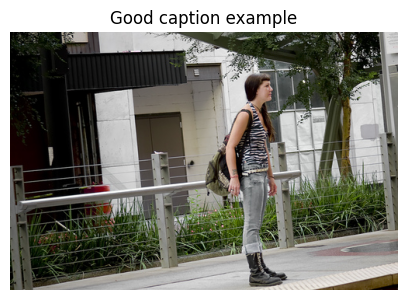

Image: 1400424834_1c76e700c4.jpg
Prediction: a woman in a black shirt and jeans is standing on a sidewalk
Reference: a lady dressed in shades of black waits on the sidewalk for a train
Sentence BLEU-1: 0.9231
--------------------------------------------------------------------------------


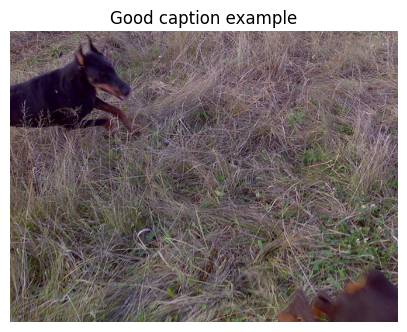

Image: 1598085252_f3219b6140.jpg
Prediction: a small dog is running through a grassy field
Reference: a dog in a field
Sentence BLEU-1: 0.8889
--------------------------------------------------------------------------------


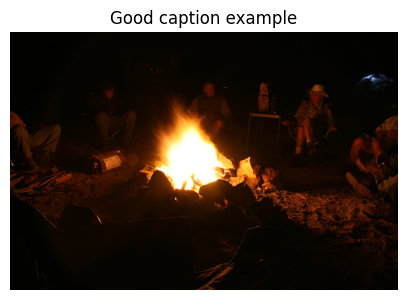

Image: 1807169176_7f5226bf5a.jpg
Prediction: a group of people are standing around a campfire
Reference: a group of people sit around a blazing fire at night
Sentence BLEU-1: 0.8889
--------------------------------------------------------------------------------


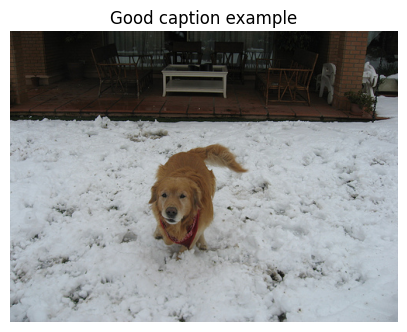

Image: 1094462889_f9966dafa6.jpg
Prediction: a brown dog is running through the snow
Reference: a brown dog plays in a deep pile of snow
Sentence BLEU-1: 0.875
--------------------------------------------------------------------------------


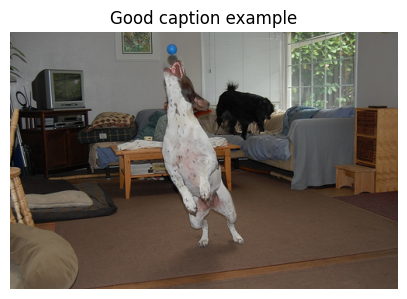

Image: 1425069308_488e5fcf9d.jpg
Prediction: a dog is playing with a white dog
Reference: a dog on two legs with its mouth opened toward a blue ball in the air
Sentence BLEU-1: 0.875
--------------------------------------------------------------------------------


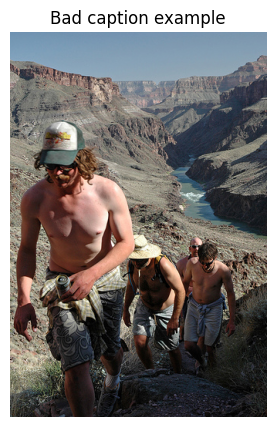

Image: 1797507760_384744fb34.jpg
Prediction: two men in a blue shirt and a man in a blue shirt and a woman in a red shirt and a white shirt is
Reference: four shirtless men are hiking up a canyon
Sentence BLEU-1: 0.08
--------------------------------------------------------------------------------


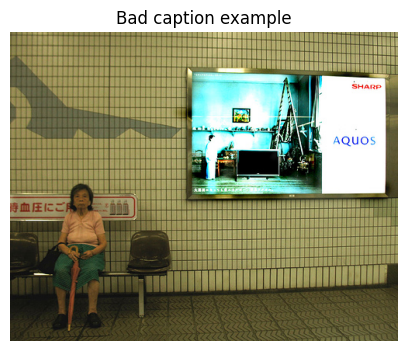

Image: 1191338263_a4fa073154.jpg
Prediction: a man in a black shirt and a woman in a black shirt and a woman in a black shirt and a white hat is
Reference: a little old lady sitting next to an advertisement
Sentence BLEU-1: 0.2
--------------------------------------------------------------------------------


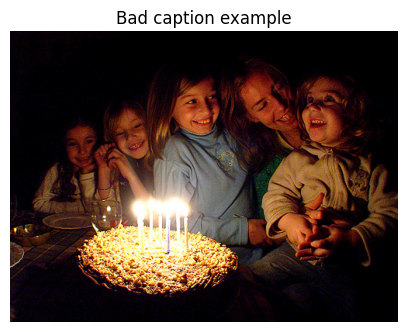

Image: 1271210445_7f7ecf3791.jpg
Prediction: a woman in a white shirt and a woman in a pink shirt is holding a baby
Reference: girls seated at table with a candle covered with lit candles
Sentence BLEU-1: 0.2353
--------------------------------------------------------------------------------


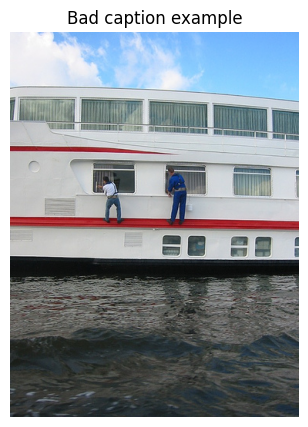

Image: 121971540_0a986ee176.jpg
Prediction: a man in a blue shirt is standing on a rock
Reference: two men cleaning the outside windows of a yacht
Sentence BLEU-1: 0.249
--------------------------------------------------------------------------------


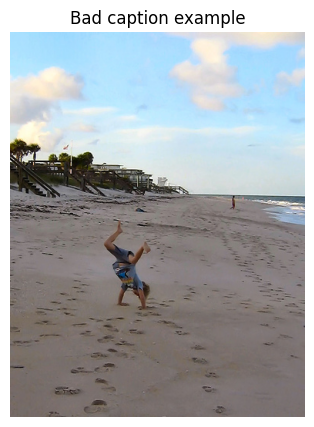

Image: 1456393634_74022d9056.jpg
Prediction: a girl in a pink bathing suit is running through the water
Reference: a boy doing a handstand on the beach
Sentence BLEU-1: 0.25
--------------------------------------------------------------------------------


In [24]:
def show_examples(examples, title):
    for _, row in examples.iterrows():
        img_path = os.path.join(images_path, row["image"])
        image = Image.open(img_path).convert("RGB")

        plt.figure(figsize=(5, 5))
        plt.imshow(image)
        plt.axis("off")
        plt.title(title)
        plt.show()

        print("Image:", row["image"])
        print("Prediction:", row["prediction"])
        print("Reference:", row["reference_1"])
        print("Sentence BLEU-1:", round(row["sentence_bleu_1"], 4))
        print("-" * 80)

show_examples(good_examples, "Good caption example")
show_examples(bad_examples, "Bad caption example")

## 16. Save Week 3 outputs

In [25]:
os.makedirs("reports", exist_ok=True)

history_df.to_csv("reports/week3_training_history.csv", index=False)
comparison_df.to_csv("reports/week3_model_comparison.csv", index=False)
good_examples.to_csv("reports/week3_good_caption_examples.csv", index=False)
bad_examples.to_csv("reports/week3_bad_caption_examples.csv", index=False)

print("Saved:")
print("- reports/week3_training_history.csv")
print("- reports/week3_model_comparison.csv")
print("- reports/week3_good_caption_examples.csv")
print("- reports/week3_bad_caption_examples.csv")

Saved:
- reports/week3_training_history.csv
- reports/week3_model_comparison.csv
- reports/week3_good_caption_examples.csv
- reports/week3_bad_caption_examples.csv
